In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../../")
import utils.data_utils as utils
import re
import seaborn as sns

hdf = pd.HDFStore('../../data/data_for_ml.h5', mode='r')
keys = hdf.keys()
df = hdf.get('/Dynamic_PsRP_1_1C')
df

,soc,direction,voltage_0.0s,voltage_1.0s,voltage_2.0s,voltage_3.0s,voltage_4.0s,voltage_5.0s,voltage_6.0s,voltage_7.0s,...,Charge depleting cycle charge throughput,Charge sustaining cycle charge efficiency,Post C/10 charge relaxation fit MSE,Post C/5 charge relaxation fit MSE,Post C/3 charge relaxation fit MSE,Post P/3 charge relaxation fit MSE,Post C/2 charge relaxation fit MSE,Post 1C charge relaxation fit MSE,Thickness growth,Volume growth
0,0.011132,charge,6.799,7.092,7.119,7.142,7.163,6.624,6.608,6.599,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
1,0.172361,charge,7.966,8.200,8.209,8.216,8.222,7.760,7.749,7.742,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
2,0.333591,charge,8.126,8.341,8.350,8.357,8.363,7.936,7.925,7.917,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
3,0.494596,charge,8.288,8.411,8.411,8.410,8.411,8.098,8.089,8.082,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
4,0.644375,charge,8.387,8.408,8.409,8.410,8.410,8.192,8.183,8.177,...,53.193351,1.254012,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4346,0.474158,discharge,3.195,3.289,3.298,3.305,3.310,3.253,3.251,3.251,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4347,0.387823,discharge,3.178,3.276,3.287,3.295,3.300,3.243,3.241,3.240,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4348,0.301488,discharge,3.151,3.253,3.267,3.276,3.282,3.225,3.222,3.221,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN
4349,0.215153,discharge,3.103,3.213,3.232,3.244,3.253,3.195,3.192,3.191,...,3.105814,1.305203,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN


In [172]:
# Determine high, medium, and low capacity cells
cell_types = ['A', 'B', 'C', 'D']
nominal_capacity = [65, 66, 26, 2.5]
categories = ['high', 'medium', 'low']

for type, cap in zip(cell_types, nominal_capacity):
    temp = df.loc[df['cell_id'].str.contains(type)]
    relative_capacity = temp['C/3 discharge capacity']/cap
    df.loc[df['cell_id'].str.contains(type), 'relative capacity'] = relative_capacity
    
    if type != 'B':
        df.loc[(df['cell_id'].str.contains(type)) & (relative_capacity > 0.9), 'capacity category'] = 'high'
        df.loc[(df['cell_id'].str.contains(type)) & (relative_capacity <= 0.9) & (relative_capacity > 0.8), 'capacity category'] = 'medium'
        df.loc[(df['cell_id'].str.contains(type)) & (relative_capacity <= 0.8), 'capacity category'] = 'low'
    else:
        df.loc[(df['cell_id'].str.contains(type)) & (relative_capacity > 0.8), 'capacity category'] = 'high'
        df.loc[(df['cell_id'].str.contains(type)) & (relative_capacity <= 0.8) & (relative_capacity > 0.7), 'capacity category'] = 'medium'
        df.loc[(df['cell_id'].str.contains(type)) & (relative_capacity <= 0.7), 'capacity category'] = 'low'



In [173]:
df

,soc,direction,voltage_0.0s,voltage_1.0s,voltage_2.0s,voltage_3.0s,voltage_4.0s,voltage_5.0s,voltage_6.0s,voltage_7.0s,...,Post C/10 charge relaxation fit MSE,Post C/5 charge relaxation fit MSE,Post C/3 charge relaxation fit MSE,Post P/3 charge relaxation fit MSE,Post C/2 charge relaxation fit MSE,Post 1C charge relaxation fit MSE,Thickness growth,Volume growth,relative capacity,capacity category
0,0.011132,charge,6.799,7.092,7.119,7.142,7.163,6.624,6.608,6.599,...,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN,0.618485,low
1,0.172361,charge,7.966,8.200,8.209,8.216,8.222,7.760,7.749,7.742,...,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN,0.618485,low
2,0.333591,charge,8.126,8.341,8.350,8.357,8.363,7.936,7.925,7.917,...,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN,0.618485,low
3,0.494596,charge,8.288,8.411,8.411,8.410,8.411,8.098,8.089,8.082,...,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN,0.618485,low
4,0.644375,charge,8.387,8.408,8.409,8.410,8.410,8.192,8.183,8.177,...,0.000015,0.000014,0.000013,0.000013,0.000013,0.000013,NaN,NaN,0.618485,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4346,0.474158,discharge,3.195,3.289,3.298,3.305,3.310,3.253,3.251,3.251,...,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN,0.960000,high
4347,0.387823,discharge,3.178,3.276,3.287,3.295,3.300,3.243,3.241,3.240,...,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN,0.960000,high
4348,0.301488,discharge,3.151,3.253,3.267,3.276,3.282,3.225,3.222,3.221,...,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN,0.960000,high
4349,0.215153,discharge,3.103,3.213,3.232,3.244,3.253,3.195,3.192,3.191,...,0.000004,0.000003,0.000101,0.000103,0.001873,0.001283,NaN,NaN,0.960000,high


# Scattered Data

Notice the huge amount of variance from the voltage pulses, with almost no correlation to the capacity.

Text(0, 0.5, 'Voltage (V)')

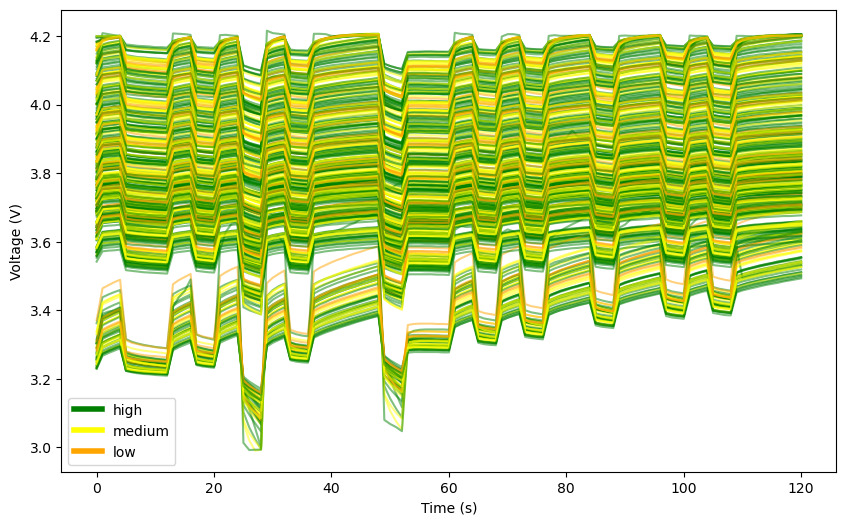

In [174]:
df_a = df[df['cell_id'].str.contains('A')] #get only type A cells

charging_data=df_a.loc[df_a.direction == 'charge'] #get only charging data

plt.figure(figsize=(10,6))
color_dict = {'high':'green', 'medium':'yellow', 'low':'orange'}

for i, row in charging_data.iterrows():
    plt.plot(range(121), row.filter(regex='voltage'), c=color_dict[row['capacity category']], alpha=0.5)
plt.legend(handles=[plt.Line2D([0], [0], color='green', lw=4, label='high'),
                    plt.Line2D([0], [0], color='yellow', lw=4, label='medium'),
                    plt.Line2D([0], [0], color='orange', lw=4, label='low')])
plt.xlabel('Time (s)') 
plt.ylabel('Voltage (V)')

As a comparison, see the correlation between the pulse voltage and state of charge (SOC)

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_7728\1156047118.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)


Text(0.5, 1.0, 'Type A Cells Charging Voltage Profiles Colored by SOC')

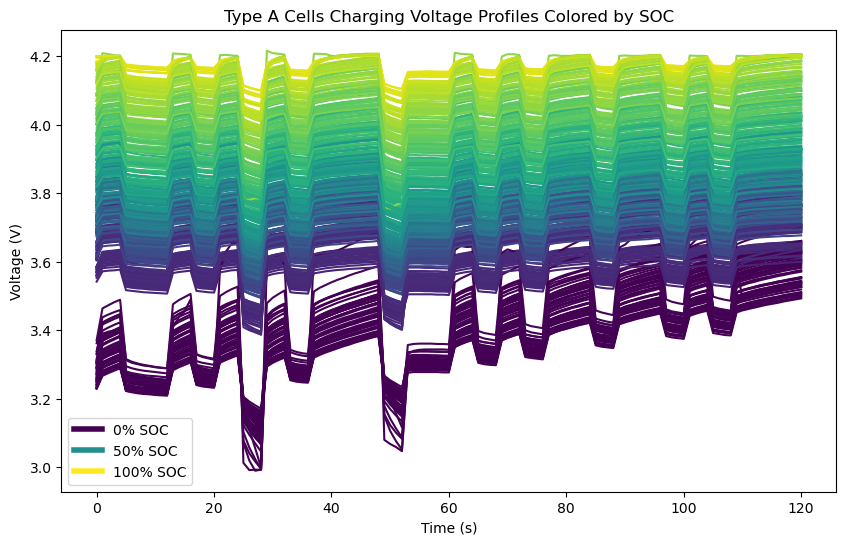

In [175]:
import matplotlib.cm as cm

cmap = cm.get_cmap('viridis', 100)

plt.figure(figsize=(10,6))
for i, row in charging_data.iterrows():
    plt.plot(range(121), row.filter(regex='voltage'), c=cmap(row.soc))
plt.legend(handles=[plt.Line2D([0], [0], color=cmap(0), lw=4, label='0% SOC'),
                    plt.Line2D([0], [0], color=cmap(49), lw=4, label='50% SOC'),
                    plt.Line2D([0], [0], color=cmap(99), lw=4, label='100% SOC')])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Type A Cells Charging Voltage Profiles Colored by SOC')


TODO: Apply PCA to the voltage pulse data, to try and classify by battery capacity

In [176]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

train_x = df_a.filter(regex='voltage')
y = df_a['capacity category']

scaler = StandardScaler()
x_scaled = scaler.fit_transform(train_x)

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

x_train, x_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.3, random_state=49994)
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
# model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
accuracy = np.mean(y_pred == y_test)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.57


c:\Users\etenney\AppData\Local\anaconda3\envs\battery_pulse_diagnostics\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


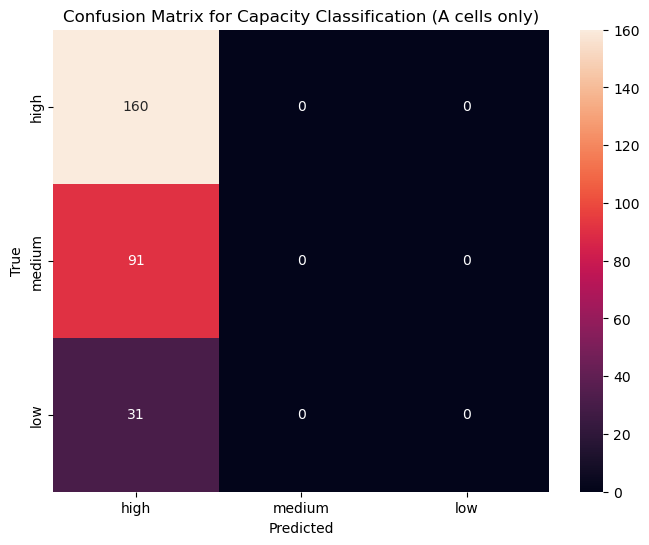

In [177]:


cm = confusion_matrix(y_test, y_pred, labels=categories)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted') 
plt.ylabel('True')
plt.title('Confusion Matrix for Capacity Classification (A cells only)')
plt.show()

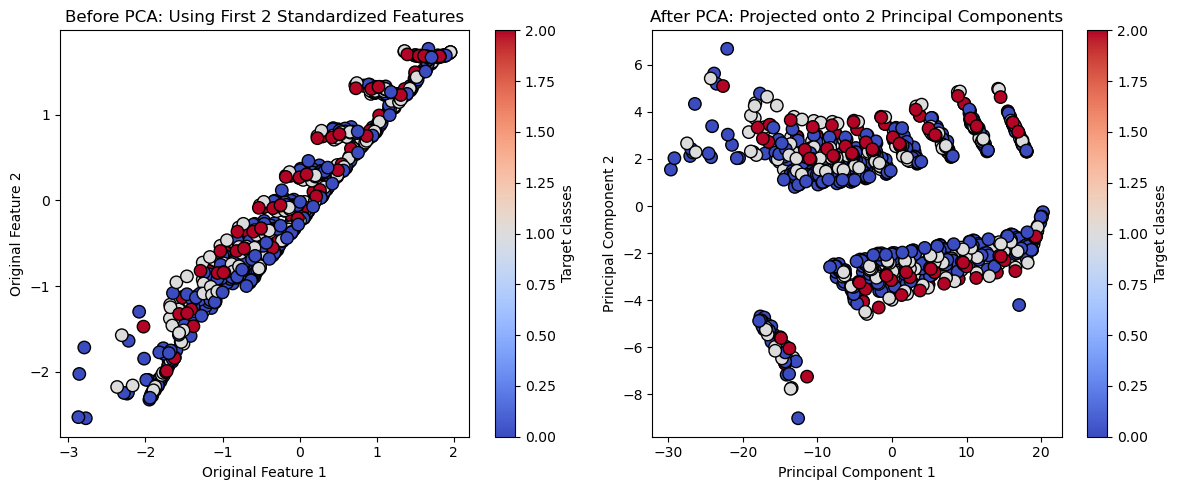

In [178]:
y_numeric = pd.factorize(y)[0]
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=y_numeric, cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()

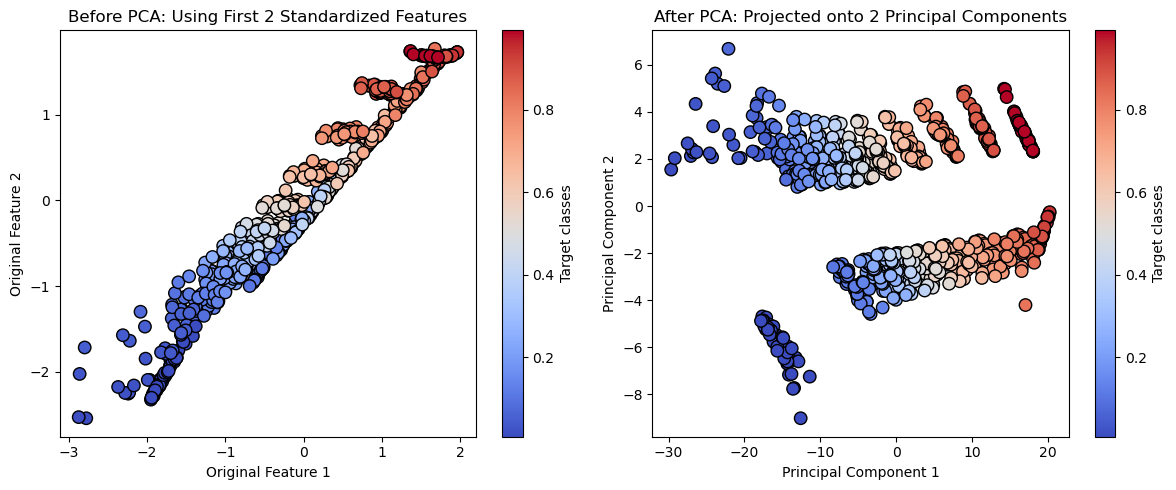

In [179]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=[x for x in df_a['soc']], cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(x_pca[:, 0], x_pca[:, 1], c=[x for x in df_a['soc']], cmap='coolwarm', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()

In [180]:
import umap
reducer = umap.UMAP()

voltage_data = df_a.filter(regex='voltage')
scaled_voltage_data = StandardScaler().fit_transform(voltage_data)

scaled_voltage_data
# voltage_data

array([[-1.8046194 , -2.11008434, -2.10197889, ..., -0.67251736,
        -0.65865701, -0.64478618],
       [-0.57686367, -0.84644197, -0.8640353 , ..., -0.29278263,
        -0.28743325, -0.28201305],
       [-0.28300737, -0.5381306 , -0.5545494 , ..., -0.02845748,
        -0.02386438, -0.02288939],
       ...,
       [-0.74593167, -0.80736025, -0.81172782, ..., -0.87727628,
        -0.87767903, -0.87429571],
       [-0.99953367, -1.07224748, -1.07762416, ..., -1.13787854,
        -1.13382342, -1.13341937],
       [-1.27326282, -1.34581954, -1.34352049, ..., -1.45060125,
        -1.45307585, -1.45177129]], shape=(938, 121))

Text(0, 0.5, 'Voltage (V)')

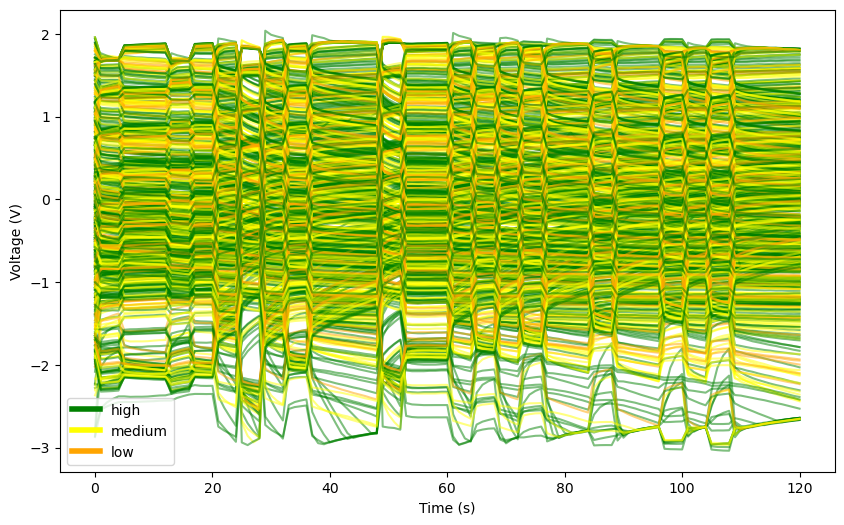

In [181]:
plt.figure(figsize=(10,6))
color_dict = {'high':'green', 'medium':'yellow', 'low':'orange'}

for i, row in enumerate(scaled_voltage_data):
    plt.plot(range(121), row, c=color_dict[df_a.iloc[i]['capacity category']], alpha=0.5)
plt.legend(handles=[plt.Line2D([0], [0], color='green', lw=4, label='high'),
                    plt.Line2D([0], [0], color='yellow', lw=4, label='medium'),
                    plt.Line2D([0], [0], color='orange', lw=4, label='low')])
plt.xlabel('Time (s)') 
plt.ylabel('Voltage (V)')

In [182]:
embedding = reducer.fit_transform(scaled_voltage_data)
embedding.shape

(938, 2)

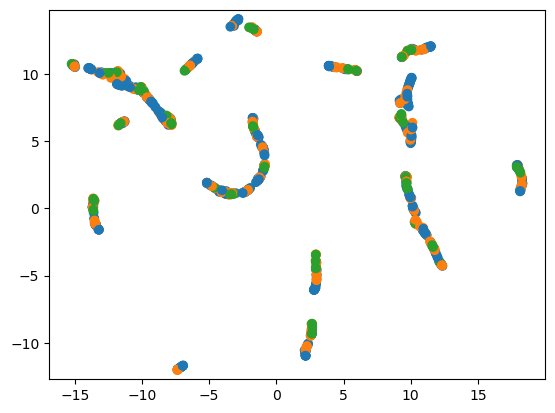

In [183]:
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette()[x] for x in df_a['capacity category'].map({"high":0, "medium":1, "low":2})])
plt.gca().set_aspect('equal', 'datalim')

C:\Users\etenney\AppData\Local\Temp\1\ipykernel_7728\4009132994.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', 100)


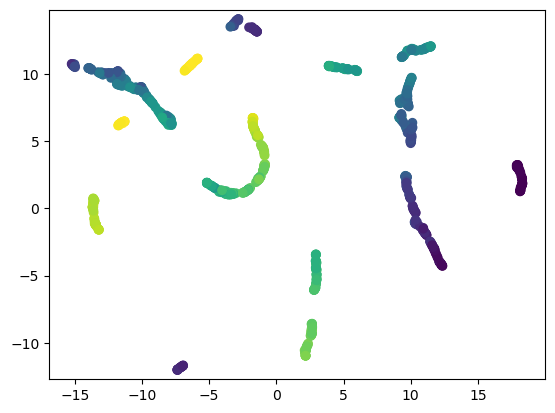

In [184]:
import matplotlib.cm as cm

cmap = cm.get_cmap('viridis', 100)

plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[cmap(x) for x in df_a['soc']])
plt.gca().set_aspect('equal', 'datalim')


In [185]:
pulse_number_in_sequence = 0
temp_measurement_id = df_a.iloc[0]['measurement_id']

for i in range(len(df_a)):
    if temp_measurement_id == df_a.iloc[i]['measurement_id']: # same measurement as previous row
        df_a.at[df_a.index[i], 'pulse_number_in_sequence'] = pulse_number_in_sequence
        pulse_number_in_sequence += 1
    else: # new measurement
        temp_measurement_id = df_a.iloc[i]['measurement_id']
        pulse_number_in_sequence = 0
        df_a.at[df_a.index[i], 'pulse_number_in_sequence'] = pulse_number_in_sequence
        pulse_number_in_sequence += 1


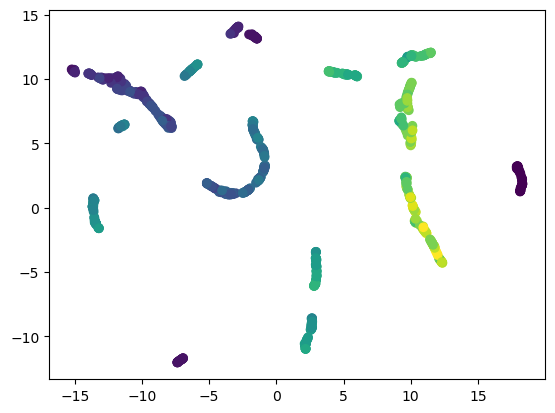

In [186]:
# Plot UMAP graph colored by pulse number in sequence
plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette("viridis", as_cmap=True)(x/df_a['pulse_number_in_sequence'].max()) for x in df_a['pulse_number_in_sequence']])